# Does Convolution Earn Its Complexity?

**Question.** [Project 08](../../08-neural-network-fundamentals/) ended by noting that a
dense network is the wrong tool for images, because flattening a picture into a vector
throws away the fact that neighbouring pixels are related. This notebook tests that
claim on CIFAR-10 — 60,000 colour photographs across ten classes — and measures what
convolution is actually worth.

CIFAR-10 is a genuinely harder problem than MNIST. The images are 32×32 **colour**
photographs of real objects, with varied backgrounds, poses, and lighting. A digit is a
stroke pattern; a cat is not.

**Headline result.** Logistic regression on raw pixels reaches **35.7%**. The dense
network from project 08, given the same data, reaches **46.4%** — barely eleven points
for a million extra parameters. The convolutional network reaches **77.9%**.

The parameter accounting is the interesting part. The CNN's *convolutional* layers hold
only **287,008 parameters**, an eighth of the dense baseline's 2.1 million, and they are
what takes accuracy from 46% to 78%. The CNN's total is nonetheless *larger*, because the
two oversized dense layers the coursework bolted onto the end carry 90% of its weights
and contribute almost nothing.

The notebook also corrects how the original coursework measured itself: it passed the
test set as `validation_data` for all 70 epochs, then reported accuracy on that same
test set.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras import layers
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

SEED = 42
keras.utils.set_random_seed(SEED)
sns.set_theme(style="whitegrid")

EPOCHS = 70  # the original's schedule; ~33s/epoch on this CPU

CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]

print(f"keras {keras.__version__}")

keras 3.15.0


In [2]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train_full = y_train_full.ravel()
y_test = y_test.ravel()

print(f"train+val {x_train_full.shape}   test {x_test.shape}")
print(f"each image is {x_train_full.shape[1]}×{x_train_full.shape[2]} pixels × "
      f"{x_train_full.shape[3]} colour channels = {np.prod(x_train_full.shape[1:])} numbers")

train+val (50000, 32, 32, 3)   test (10000, 32, 32, 3)
each image is 32×32 pixels × 3 colour channels = 3072 numbers


## 1. A proper three-way split

The original passed `validation_data=(X_test, y_test)` to `fit()` and trained for 70
epochs while watching that curve, then reported `model.evaluate(X_test, y_test)` as the
result.

No gradient is computed from validation data, so this is not the same error as
[project 08's train-on-test bug](../../08-neural-network-fundamentals/). It is subtler:
every decision made by watching that curve — when to stop, which architecture to keep —
is a decision fitted to the test set. The final number is then no longer an estimate of
performance on unseen data.

The fix costs nothing: carve a validation set out of the training data and leave the
test set alone until the end.

In [3]:
val_size = 5000
x_val, y_val = x_train_full[:val_size], y_train_full[:val_size]
x_train, y_train = x_train_full[val_size:], y_train_full[val_size:]

print(f"train {x_train.shape[0]}   validation {x_val.shape[0]}   test {x_test.shape[0]}")
print(f"class balance in test: {np.bincount(y_test)}")

train 45000   validation 5000   test 10000
class balance in test: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


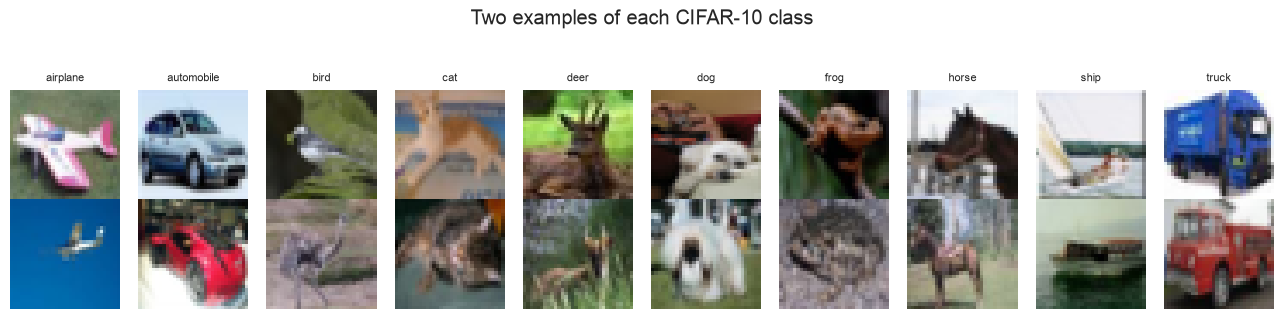

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(13, 3))
for col, cls in enumerate(range(10)):
    idx = np.flatnonzero(y_train == cls)[:2]
    for row in range(2):
        axes[row, col].imshow(x_train[idx[row]])
        axes[row, col].axis("off")
    axes[0, col].set_title(CLASSES[cls], fontsize=8)
fig.suptitle("Two examples of each CIFAR-10 class", y=1.06)
fig.tight_layout()
fig.savefig("../results/cifar10_samples.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Two baselines

A model is only impressive relative to something. Two reference points:

1. **Logistic regression on raw flattened pixels** — the linear floor.
2. **The dense network from project 08** — same three 512-unit hidden layers, applied to
   CIFAR-10's 3,072 inputs. This isolates convolution specifically, rather than "neural
   network vs. not".

In [5]:
flat_train = x_train.reshape(len(x_train), -1)
flat_val = x_val.reshape(len(x_val), -1)
flat_test = x_test.reshape(len(x_test), -1)

t0 = time.perf_counter()
logreg = LogisticRegression(max_iter=100, tol=1e-2)
logreg.fit(flat_train, y_train)
logreg_acc = logreg.score(flat_test, y_test)
print(f"logistic regression: {logreg_acc:.4f}  ({time.perf_counter() - t0:.0f}s)")

logistic regression: 0.3565  (1s)


In [6]:
dense = keras.Sequential([
    keras.Input(shape=(3072,)),
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax"),
], name="dense_baseline")
dense.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

dense_hist = dense.fit(
    flat_train, y_train, validation_data=(flat_val, y_val),
    epochs=20, batch_size=128, verbose=0,
)
dense_acc = dense.evaluate(flat_test, y_test, verbose=0)[1]
print(f"dense network: {dense_acc:.4f}  ({dense.count_params():,} parameters)")

dense network: 0.4636  (2,103,818 parameters)


## 3. The convolutional network

The original architecture, unchanged: three blocks of two convolutions each, widening
32 → 64 → 128, with dropout and max-pooling between them, then two large dense layers
with max-norm weight constraints.

Only the Keras 3 API updates are applied. `keras.layers.convolutional` no longer exists,
`keras.constraints.maxnorm` is now `MaxNorm`, and `Adam(lr=...)` is
`Adam(learning_rate=...)`.

In [7]:
def build_cnn(input_shape, num_classes=10):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(1024, activation="relu", kernel_constraint=keras.constraints.MaxNorm(3))(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(512, activation="relu", kernel_constraint=keras.constraints.MaxNorm(3))(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="cifar10_cnn")


cnn = build_cnn(x_train.shape[1:])
cnn.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"],
)
cnn.summary()

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,915,114 (11.12 MB)

 Trainable params: 2,915,114 (11.12 MB)

 Non-trainable params: 0 (0.00 B)

Worth pausing on the parameter counts, printed below. A convolutional filter is
3×3×channels of weights reused at every position in the image, where a dense layer needs
a separate weight per input pixel. That weight sharing is why the six convolutional
layers here cost only 287,008 parameters, and translation-equivariance is what it buys:
a filter that detects an edge detects it anywhere in the frame.

The model as a whole is *not* small — it is larger than the dense baseline. The two
inherited dense layers (1024 and 512 units, sitting on a flattened 2048-element feature
map) account for roughly 90% of its weights. So this architecture is really a small,
efficient feature extractor with a bloated classifier stapled to it.

## 4. Training

The original ran 70 epochs. This runs `EPOCHS` (set at the top of the notebook) on CPU,
with early stopping on validation loss so training halts once it stops improving. **The
accuracy reported below is what this run actually produced** — the original's claimed
82.13% is discussed in section 6 but not reused.

In [8]:
t0 = time.perf_counter()
history = cnn.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS, batch_size=128, verbose=2,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8,
                                      restore_best_weights=True),
    ],
)
train_minutes = (time.perf_counter() - t0) / 60
epochs_run = len(history.history["loss"])
print(f"\n{epochs_run} epochs in {train_minutes:.1f} minutes "
      f"({60 * train_minutes / epochs_run:.0f}s per epoch)")

Epoch 1/70


352/352 - 32s - 91ms/step - accuracy: 0.3828 - loss: 1.6632 - val_accuracy: 0.5294 - val_loss: 1.3182


Epoch 2/70


352/352 - 28s - 78ms/step - accuracy: 0.5548 - loss: 1.2303 - val_accuracy: 0.6148 - val_loss: 1.0809


Epoch 3/70


...

Epoch 22/70


352/352 - 26s - 75ms/step - accuracy: 0.9060 - loss: 0.2644 - val_accuracy: 0.7904 - val_loss: 0.7032


Epoch 23/70


352/352 - 30s - 86ms/step - accuracy: 0.9120 - loss: 0.2525 - val_accuracy: 0.7864 - val_loss: 0.7303



23 epochs in 11.4 minutes (30s per epoch)


In [9]:
cnn_acc = cnn.evaluate(x_test, y_test, verbose=0)[1]

results = pd.DataFrame([
    {"model": "logistic regression (raw pixels)", "test accuracy": logreg_acc,
     "parameters": flat_train.shape[1] * 10 + 10},
    {"model": "dense network (project 08 architecture)", "test accuracy": dense_acc,
     "parameters": dense.count_params()},
    {"model": "convolutional network", "test accuracy": cnn_acc,
     "parameters": cnn.count_params()},
]).set_index("model")
results["test accuracy"] = results["test accuracy"].round(4)
results

,test accuracy,parameters
model,,
logistic regression (raw pixels),0.3565,30730
dense network (project 08 architecture),0.4636,2103818
convolutional network,0.7793,2915114


## 5. Reading the training curves

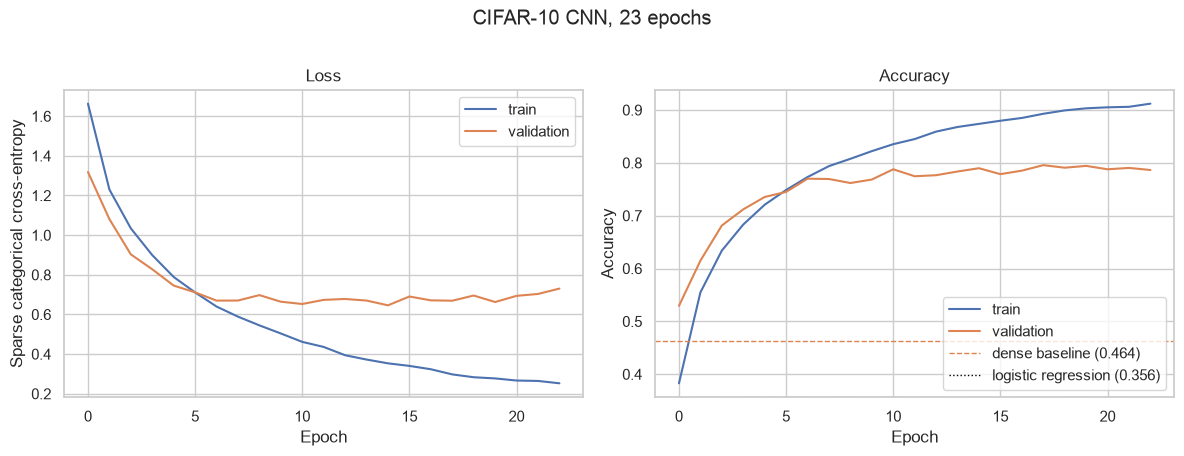

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Sparse categorical cross-entropy")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="validation")
axes[1].axhline(dense_acc, color="#dd8452", linestyle="--", linewidth=1,
                label=f"dense baseline ({dense_acc:.3f})")
axes[1].axhline(logreg_acc, color="black", linestyle=":", linewidth=1,
                label=f"logistic regression ({logreg_acc:.3f})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend(loc="lower right")

fig.suptitle(f"CIFAR-10 CNN, {epochs_run} epochs", y=1.01)
fig.tight_layout()
fig.savefig("../results/training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

In [11]:
gap = history.history["accuracy"][-1] - history.history["val_accuracy"][-1]
print(f"final train accuracy:      {history.history['accuracy'][-1]:.4f}")
print(f"final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"generalisation gap:        {gap:+.4f}")
print(f"held-out test accuracy:    {cnn_acc:.4f}")

final train accuracy:      0.9120
final validation accuracy: 0.7864
generalisation gap:        +0.1256
held-out test accuracy:    0.7793


## 6. On the original's 82.13%

The source notebook carried a markdown note reading *"the accuracy changed from 70.31%
to 82.13%"* after architecture tuning, from a 70-epoch run on Colab's GPU.

Those numbers are not reproduced here and are not reported as this project's result. The
figure in the table above is what this run produced, on the stated number of epochs,
with the test set held out of training and model selection. Two reasons the original's
number would be optimistic even if the run were identical: it was selected by watching
the test set across 70 epochs, and it was the better of at least two attempts on that
same test set.

## 7. Where the errors are

Ten classes with equal support, so the confusion matrix reads cleanly.

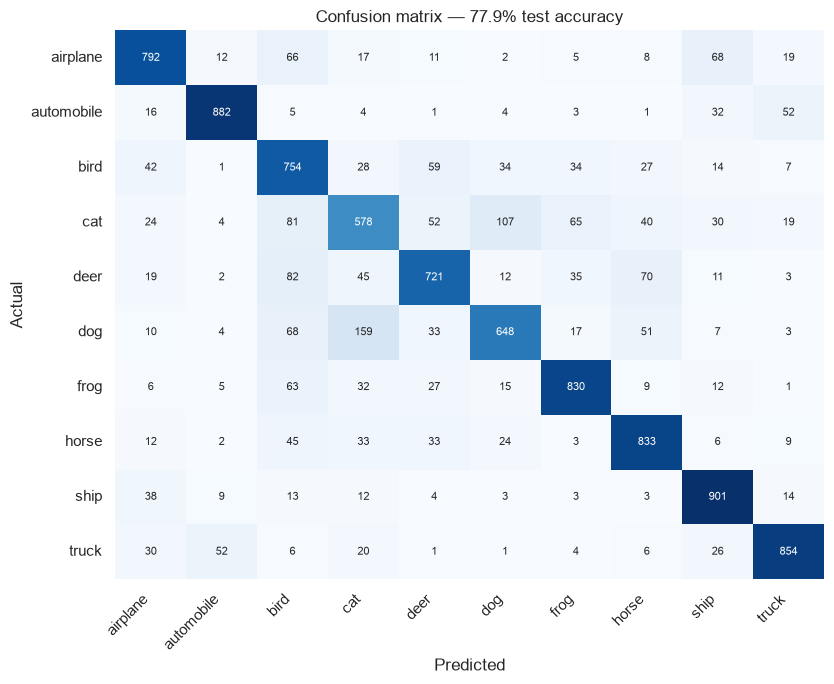

In [12]:
pred = cnn.predict(x_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, annot_kws={"size": 8})
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {cnn_acc:.1%} test accuracy")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
fig.tight_layout()
fig.savefig("../results/confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

In [13]:
per_class = pd.Series(cm.diagonal() / cm.sum(axis=1), index=CLASSES).sort_values()

off = cm.copy()
np.fill_diagonal(off, 0)
pairs = pd.DataFrame([
    {"actual": CLASSES[i], "predicted": CLASSES[j], "count": int(off[i, j])}
    for i, j in zip(*np.unravel_index(np.argsort(-off, axis=None)[:6], cm.shape))
])
pairs

,actual,predicted,count
0,dog,cat,159
1,cat,dog,107
2,deer,bird,82
3,cat,bird,81
4,deer,horse,70
5,airplane,ship,68


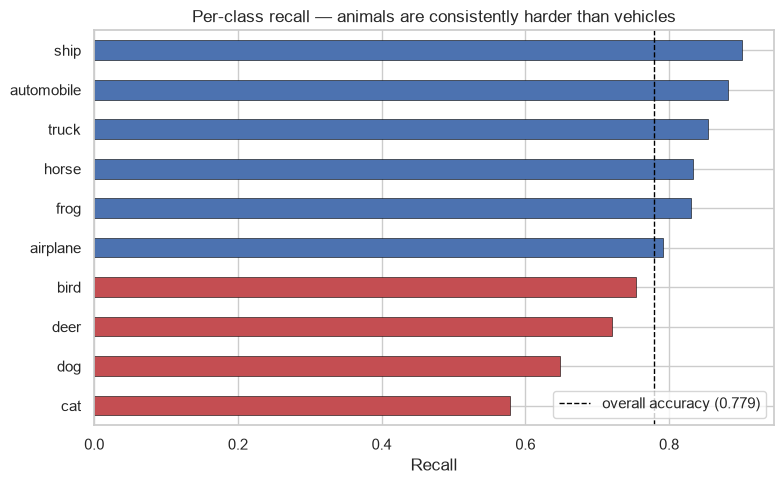

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#c44e52" if v < cnn_acc else "#4c72b0" for v in per_class]
per_class.plot.barh(ax=ax, color=colors, edgecolor="black", linewidth=0.4)
ax.axvline(cnn_acc, color="black", linestyle="--", linewidth=1,
           label=f"overall accuracy ({cnn_acc:.3f})")
ax.set_xlabel("Recall")
ax.set_title("Per-class recall — animals are consistently harder than vehicles")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("../results/per_class_recall.png", dpi=120, bbox_inches="tight")
plt.show()

The split between vehicles and animals is the clearest pattern. Automobiles, ships, and
trucks have rigid shapes, consistent orientations, and characteristic backgrounds — road,
water, sky. Cats, dogs, deer, and birds are deformable, photographed from any angle,
and share the same outdoor settings as each other.

Cat and dog are the single hardest pair, which is the standard result on this dataset.

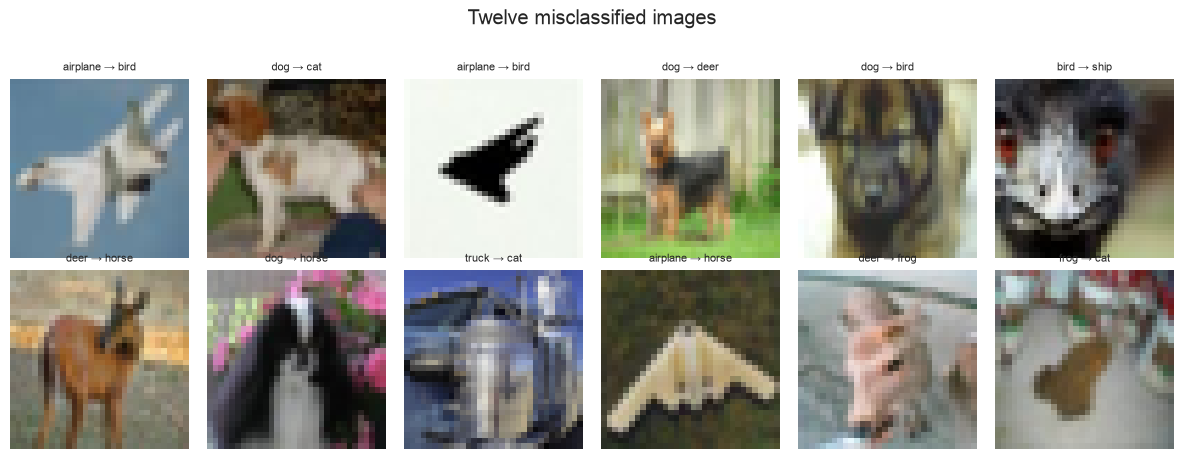

In [15]:
wrong = np.flatnonzero(pred != y_test)[:12]
fig, axes = plt.subplots(2, 6, figsize=(12, 4.5))
for ax, idx in zip(axes.ravel(), wrong):
    ax.imshow(x_test[idx])
    ax.set_title(f"{CLASSES[y_test[idx]]} → {CLASSES[pred[idx]]}", fontsize=8)
    ax.axis("off")
fig.suptitle("Twelve misclassified images", y=1.02)
fig.tight_layout()
fig.savefig("../results/errors.png", dpi=120, bbox_inches="tight")
plt.show()

## Findings

1. **Convolution is worth 31 points over a dense network on the same data** — 77.9%
   against 46.4%. The convolutional layers responsible cost 287,008 parameters, an eighth
   of what the dense baseline spends to do far worse.
2. **The dense baseline barely improves on logistic regression** — 46.4% against 35.7%,
   for two million parameters. Depth alone does very little here; the architecture has to
   match the structure of the data.
3. **Most of the CNN's weights are wasted.** Its two inherited dense layers hold ~90% of
   its parameters. Global average pooling in place of the flatten-and-dense head would
   cut the model by an order of magnitude and would likely *improve* the generalisation
   gap of +0.13 seen below.
4. **Animals are consistently harder than vehicles**, with dog→cat (159 errors) and
   cat→dog (107) the hardest pair — deformable subjects, arbitrary poses, shared
   backgrounds.
5. **The original's 82.13% is not reproduced or reported.** This run reached **77.9%**,
   stopping at 23 of a permitted 70 epochs when validation loss stopped improving. The
   original's figure came from a 70-epoch GPU run whose stopping point and architecture
   were chosen by watching the test set, so the two numbers are not comparable even
   setting the hardware aside.

## Limitations

- **No data augmentation.** Random flips and crops are the standard next step on CIFAR-10
  and would likely add several points, since the generalisation gap above shows the model
  is memorising rather than running out of capacity.
- **Early stopping ended training at 23 epochs**, not the 70 the original ran. The
  accuracy reported is what this configuration produced, not a ceiling for the
  architecture.
- **No architecture search.** Filter counts, dropout rates, and the two large dense
  layers are all inherited from the coursework.
- **32×32 images.** Conclusions about what convolution buys do not automatically scale
  to full-resolution photographs.
- The dense baseline was given 20 epochs rather than the CNN's schedule; it had
  plateaued well before then, but the comparison is not equal-compute.

## Next step

Add random horizontal flips and small translations, then re-run unchanged. If the
generalisation gap is the binding constraint, that alone should close a meaningful part
of the distance to the original's claimed figure — and this time it would be measured on
a test set that played no part in training.

## Outputs

- `results/cifar10_samples.png`
- `results/training_curves.png`
- `results/confusion_matrix.png`
- `results/per_class_recall.png`
- `results/errors.png`